In [1]:
import numpy as np  # For numerical computations
import pandas as pd  # Data handling, CSV I/O operations

from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA


from matplotlib import pyplot as plt
import seaborn as sns


import folium
from folium.plugins import MarkerCluster, HeatMap


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


import os
input_directory = '/kaggle/input'

for root_dir, _, files in os.walk(input_directory):
    for file in files:
        file_path = os.path.join(root_dir, file)
        print(file_path)

/kaggle/input/flood-risk-in-india/flood_risk_dataset_india.csv


In [2]:
dataset_path = '/kaggle/input/flood-risk-in-india/flood_risk_dataset_india.csv'
data = pd.read_csv(dataset_path)

# Display first few rows of the dataset
data.sample(5)  # Displaying 5 random rows for better data inspection

,Latitude,Longitude,Rainfall (mm),Temperature (°C),Humidity (%),River Discharge (m³/s),Water Level (m),Elevation (m),Land Cover,Soil Type,Population Density,Infrastructure,Historical Floods,Flood Occurred
2543,25.794519,74.314142,255.704340,20.517286,75.936354,3178.601405,7.730885,4602.186734,Desert,Loam,6828.857259,1,1,1
8914,10.430321,88.133683,115.207375,15.167066,71.412826,774.893094,6.781193,7224.570910,Agricultural,Silt,6257.777457,1,0,0
1419,35.082376,83.377178,162.843269,17.593689,24.340509,2130.742398,4.484765,6483.409123,Water Body,Loam,5929.865147,0,0,0
3294,36.073909,77.391639,276.206532,43.098813,83.032681,4946.454490,0.587775,2695.845182,Agricultural,Sandy,121.813180,1,1,1
5412,29.357722,93.605621,245.177643,28.549231,93.283947,345.281304,0.117054,7025.872877,Forest,Silt,2375.708484,1,0,0


In [3]:
missing_values = data.isna().sum()
missing_values

Latitude                  0
Longitude                 0
Rainfall (mm)             0
Temperature (°C)          0
Humidity (%)              0
River Discharge (m³/s)    0
Water Level (m)           0
Elevation (m)             0
Land Cover                0
Soil Type                 0
Population Density        0
Infrastructure            0
Historical Floods         0
Flood Occurred            0
dtype: int64

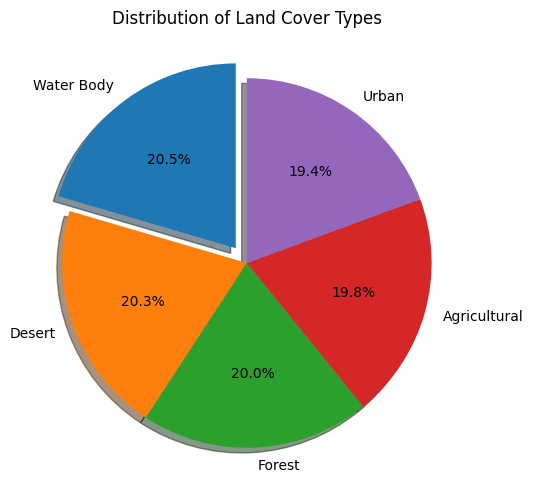

In [4]:
land_cover_data = data['Land Cover']

# Count the occurrences of each category
land_cover_counts = land_cover_data.value_counts()

# Customize pie chart explosion for highlighting the first segment
explode_values = [0.1 if idx == 0 else 0 for idx in range(len(land_cover_counts))]

# Plotting the pie chart
plt.figure(figsize=(10, 6))
plt.pie(
    land_cover_counts,
    labels=land_cover_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=explode_values
)
plt.title('Distribution of Land Cover Types')
plt.show()


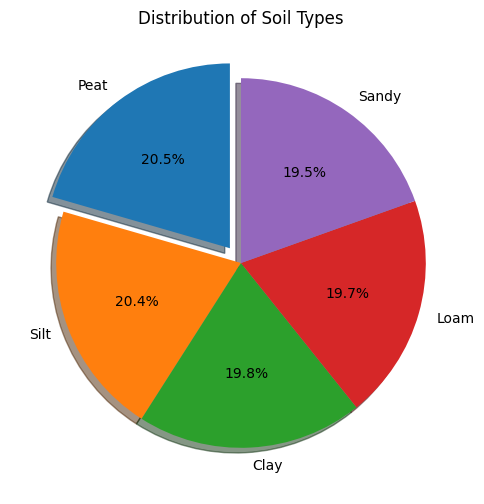

In [5]:
soil_type_data = data['Soil Type']

# Count the occurrences of each soil type category
soil_type_counts = soil_type_data.value_counts()

# Define explosion settings to highlight the first category in the pie chart
explode_settings = [0.1 if index == 0 else 0 for index in range(len(soil_type_counts))]

# Plot the pie chart for soil types
plt.figure(figsize=(10, 6))
plt.pie(
    soil_type_counts,
    labels=soil_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    explode=explode_settings
)
plt.title('Distribution of Soil Types')
plt.show()

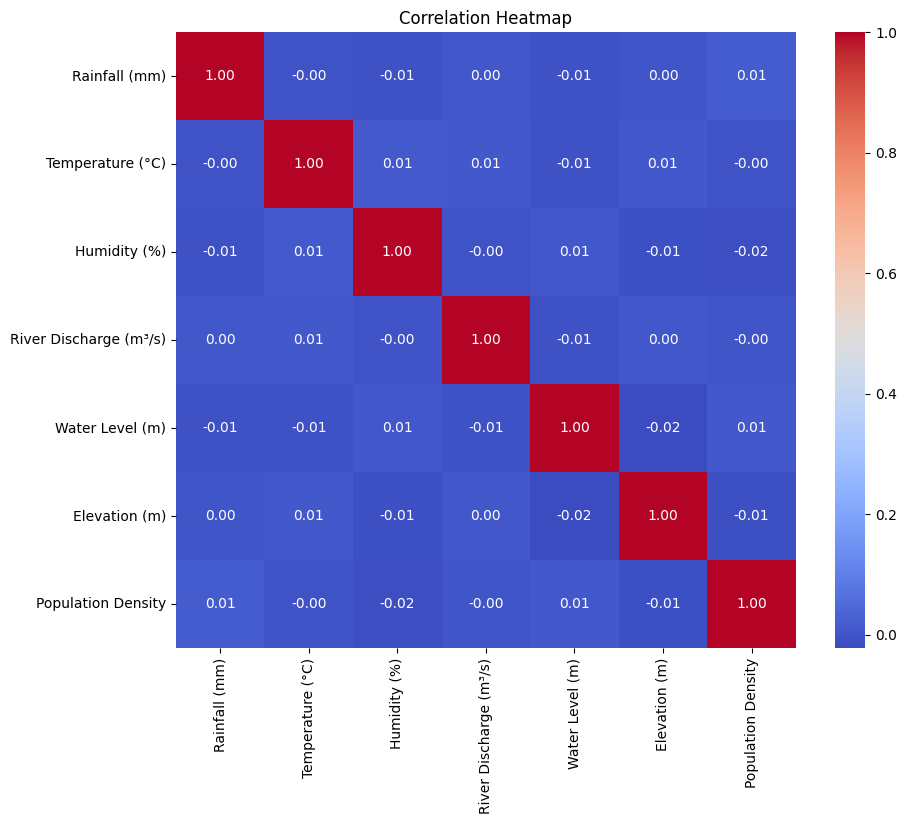

In [6]:
numerical_features = data[['Rainfall (mm)', 'Temperature (°C)', 'Humidity (%)', 
                           'River Discharge (m³/s)', 'Water Level (m)', 
                           'Elevation (m)', 'Population Density']]

# Set up the figure size and title for the correlation heatmap
plt.figure(figsize=(10, 8))
plt.title("Correlation Heatmap")

# Generate the correlation heatmap with annotations
sns.heatmap(
    numerical_features.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.show()

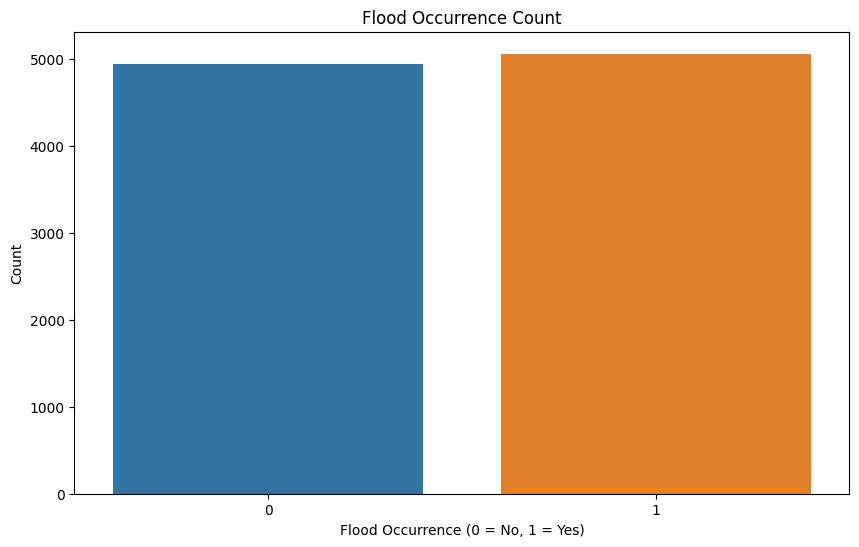

In [7]:
plt.figure(figsize=(10, 6))

# Generate the count plot for flood occurrence
sns.countplot(x='Flood Occurred', data=data)

# Label the x-axis to clarify the flood occurrence categories
plt.xlabel('Flood Occurrence (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Flood Occurrence Count')
plt.show()

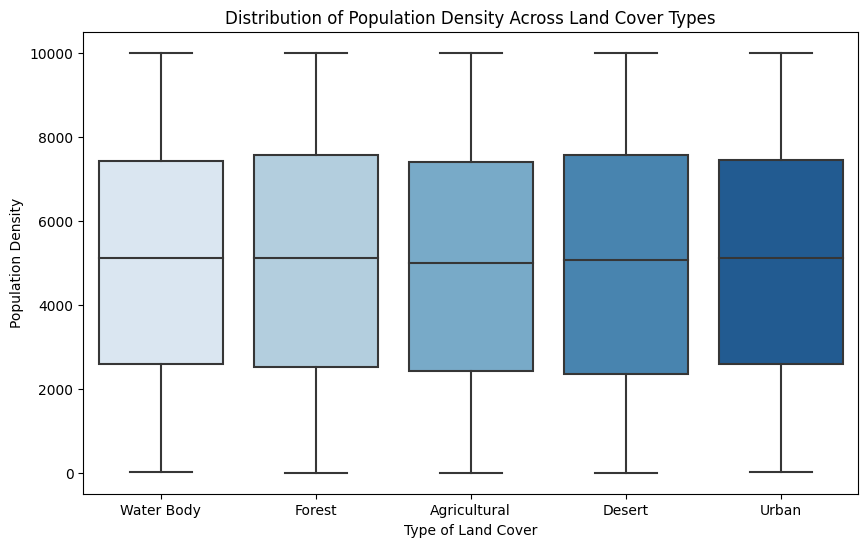

In [8]:
plt.figure(figsize=(10, 6))

# Create a box plot to show Population Density by Land Cover category
sns.boxplot(x='Land Cover', y='Population Density', data=data, palette='Blues')

# Add plot title and axis labels
plt.title('Distribution of Population Density Across Land Cover Types')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Type of Land Cover')
plt.ylabel('Population Density')
plt.show()

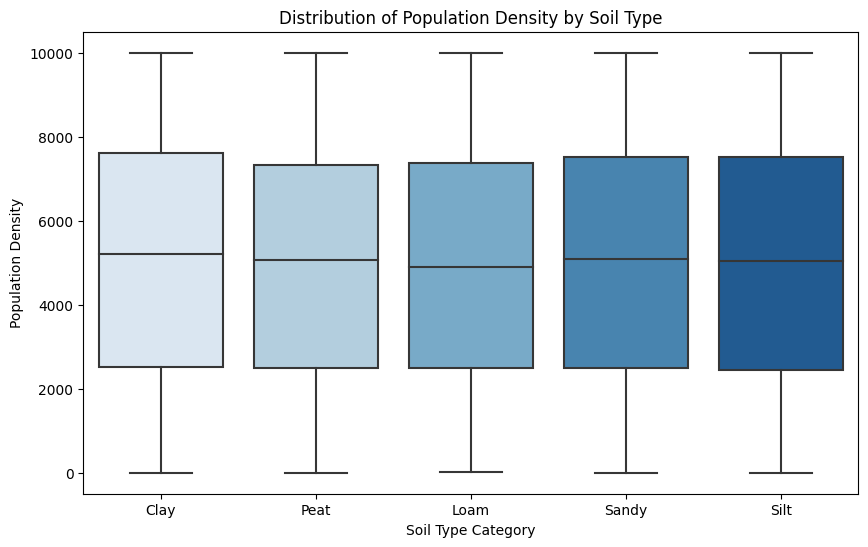

In [9]:
plt.figure(figsize=(10, 6))

# Create a boxplot to examine Population Density across Soil Type categories
sns.boxplot(x='Soil Type', y='Population Density', data=data, palette='Blues')

# Add title and labels for clarity
plt.title('Distribution of Population Density by Soil Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Soil Type Category')
plt.ylabel('Population Density')
plt.show()

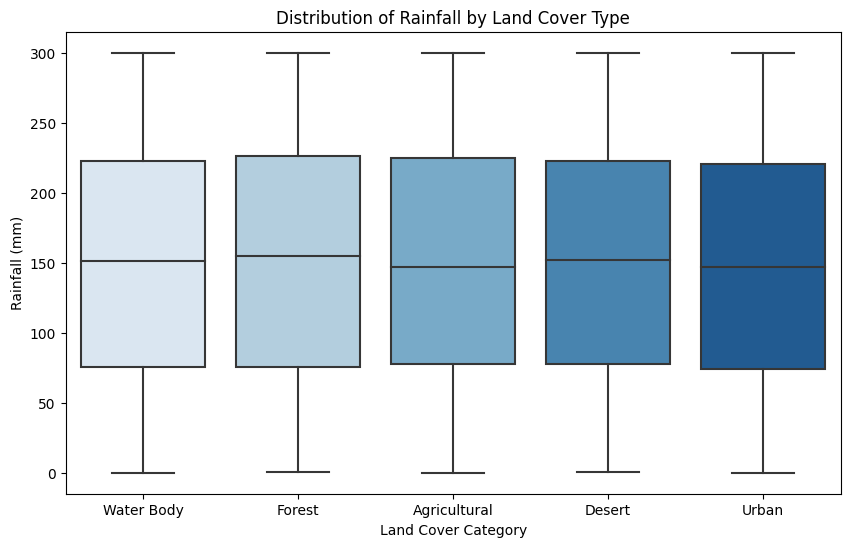

In [10]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Rainfall distribution by Land Cover type
sns.boxplot(x='Land Cover', y='Rainfall (mm)', data=data, palette='Blues')

# Add title and labels for better understanding
plt.title('Distribution of Rainfall by Land Cover Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Land Cover Category')
plt.ylabel('Rainfall (mm)')
plt.show()

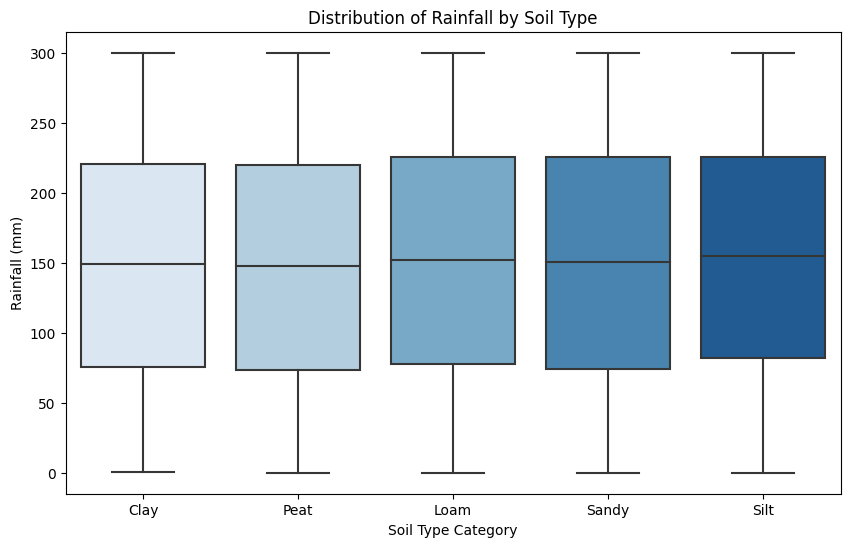

In [11]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize the distribution of Rainfall by Soil Type
sns.boxplot(x='Soil Type', y='Rainfall (mm)', data=data, palette='Blues')

# Set the title and labels for clarity
plt.title('Distribution of Rainfall by Soil Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Soil Type Category')
plt.ylabel('Rainfall (mm)')
plt.show()

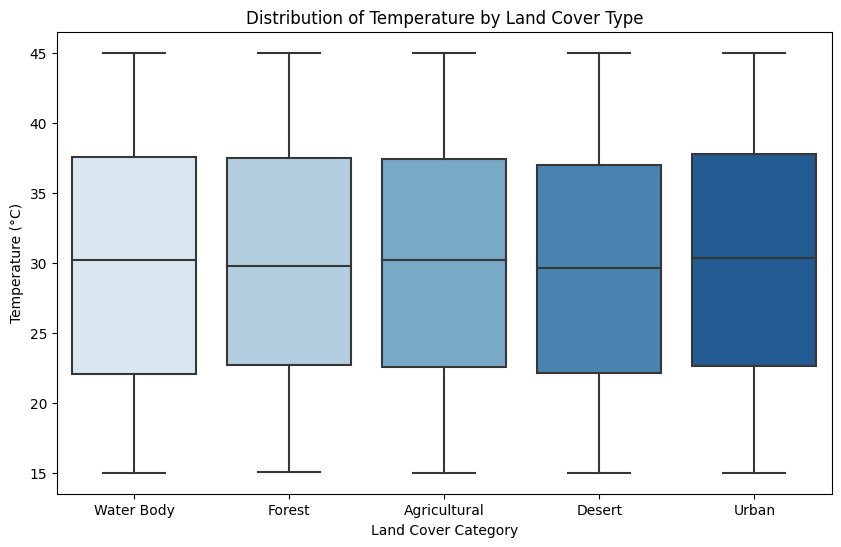

In [12]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Temperature distribution by Land Cover type
sns.boxplot(x='Land Cover', y='Temperature (°C)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Temperature by Land Cover Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Land Cover Category')
plt.ylabel('Temperature (°C)')
plt.show()

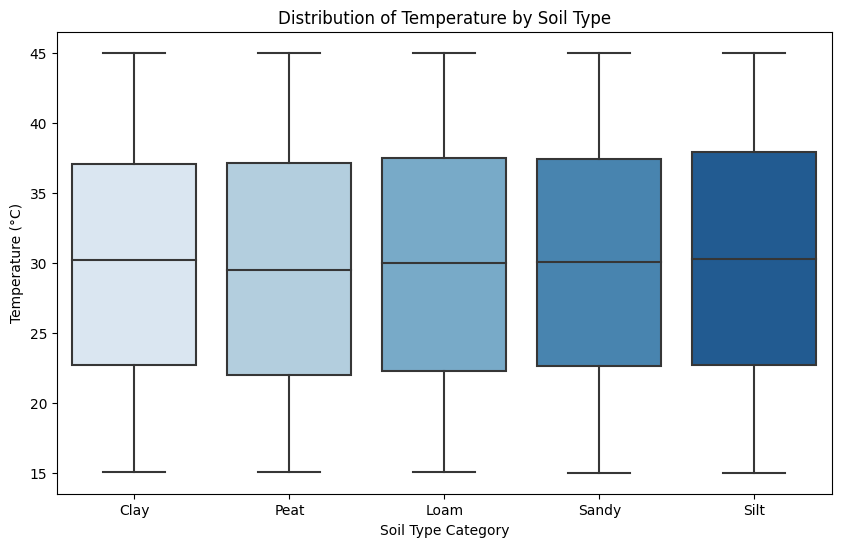

In [13]:
plt.figure(figsize=(10, 6))

# Create a boxplot to show Temperature distribution by Soil Type
sns.boxplot(x='Soil Type', y='Temperature (°C)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Temperature by Soil Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Soil Type Category')
plt.ylabel('Temperature (°C)')
plt.show()

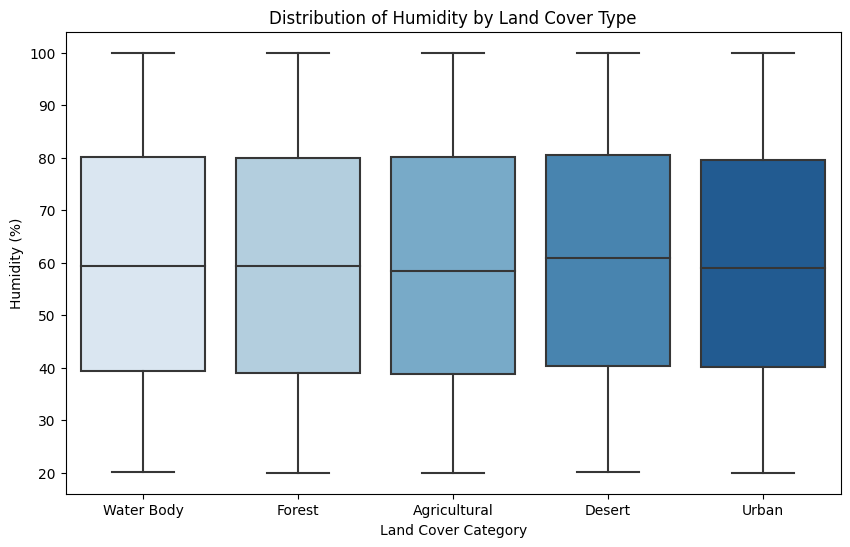

In [14]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Humidity distribution by Land Cover type
sns.boxplot(x='Land Cover', y='Humidity (%)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Humidity by Land Cover Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Land Cover Category')
plt.ylabel('Humidity (%)')
plt.show()

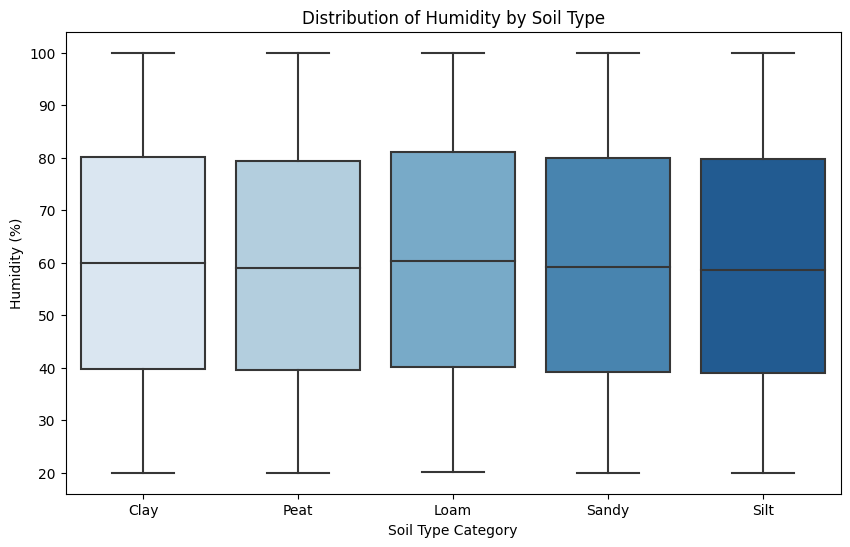

In [15]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Humidity distribution by Soil Type
sns.boxplot(x='Soil Type', y='Humidity (%)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Humidity by Soil Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Soil Type Category')
plt.ylabel('Humidity (%)')
plt.show()

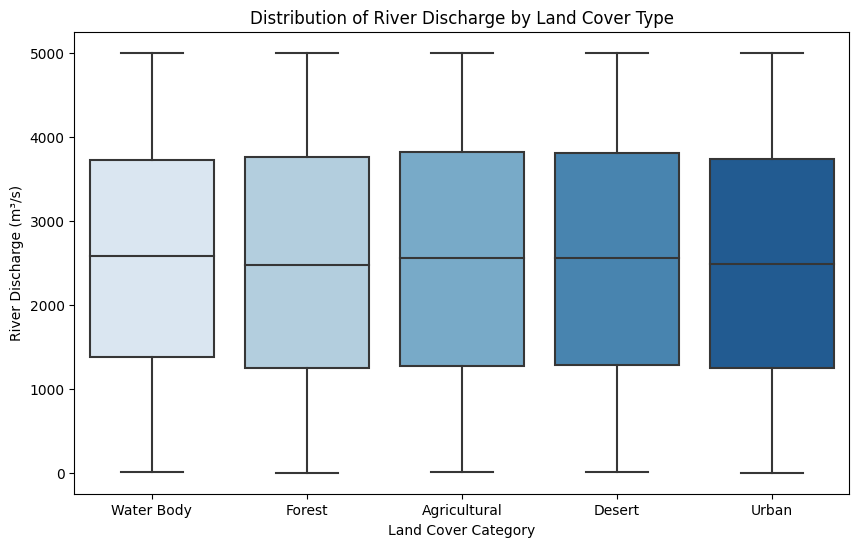

In [16]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize River Discharge distribution by Land Cover type
sns.boxplot(x='Land Cover', y='River Discharge (m³/s)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of River Discharge by Land Cover Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Land Cover Category')
plt.ylabel('River Discharge (m³/s)')
plt.show()

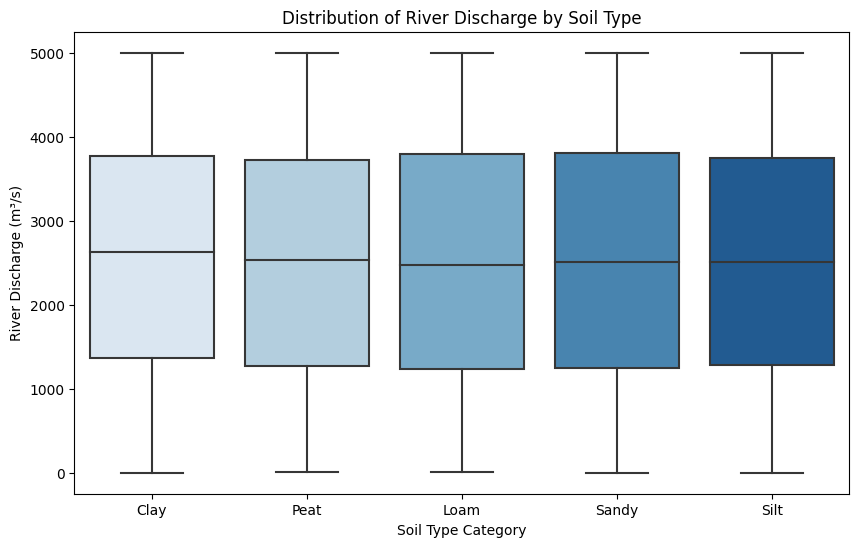

In [17]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize River Discharge distribution by Soil Type
sns.boxplot(x='Soil Type', y='River Discharge (m³/s)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of River Discharge by Soil Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Soil Type Category')
plt.ylabel('River Discharge (m³/s)')
plt.show()

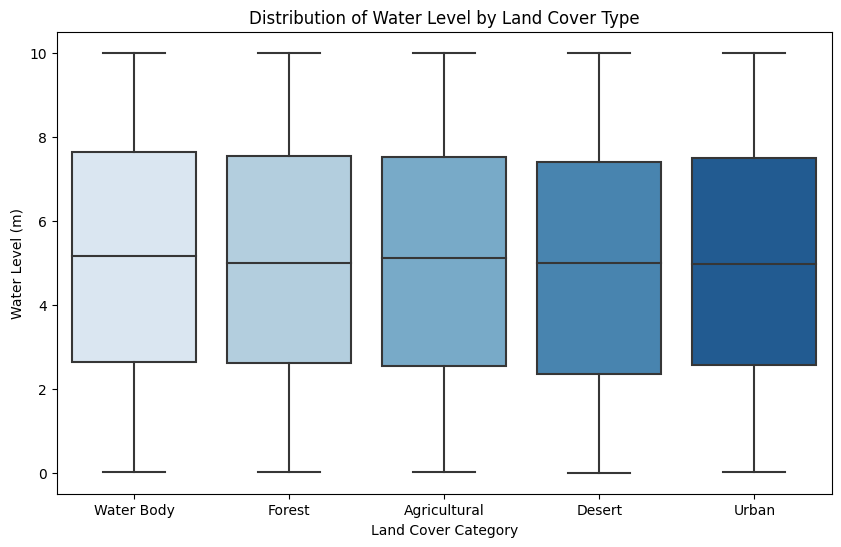

In [18]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Water Level distribution by Land Cover type
sns.boxplot(x='Land Cover', y='Water Level (m)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Water Level by Land Cover Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Land Cover Category')
plt.ylabel('Water Level (m)')
plt.show()

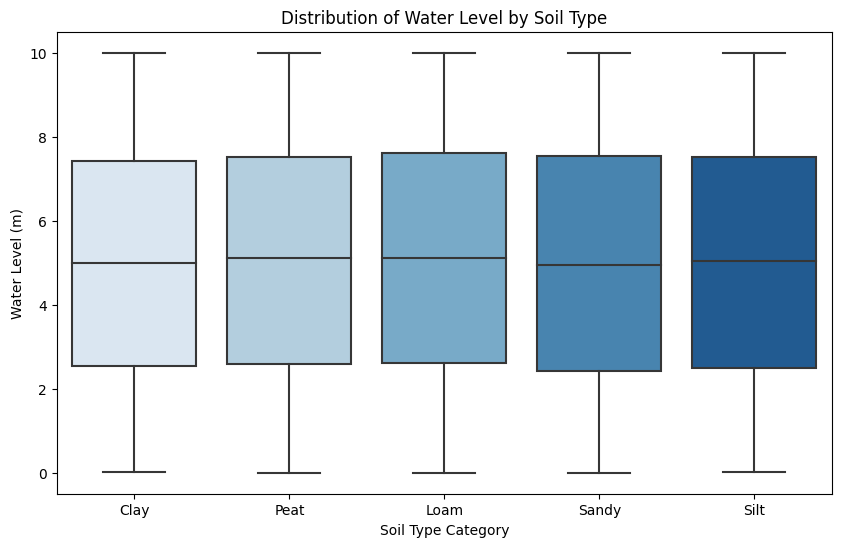

In [19]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Water Level distribution by Soil Type
sns.boxplot(x='Soil Type', y='Water Level (m)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Water Level by Soil Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Soil Type Category')
plt.ylabel('Water Level (m)')
plt.show()

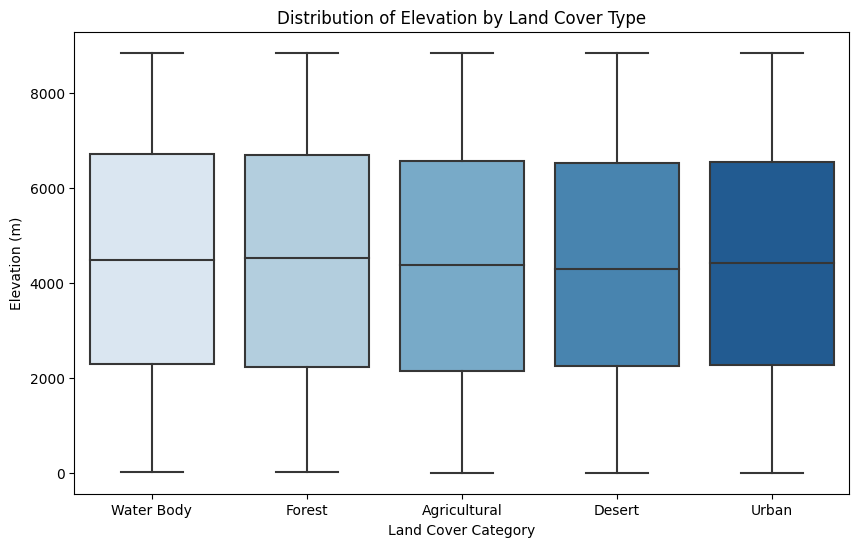

In [20]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Elevation distribution by Land Cover type
sns.boxplot(x='Land Cover', y='Elevation (m)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Elevation by Land Cover Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Land Cover Category')
plt.ylabel('Elevation (m)')
plt.show()

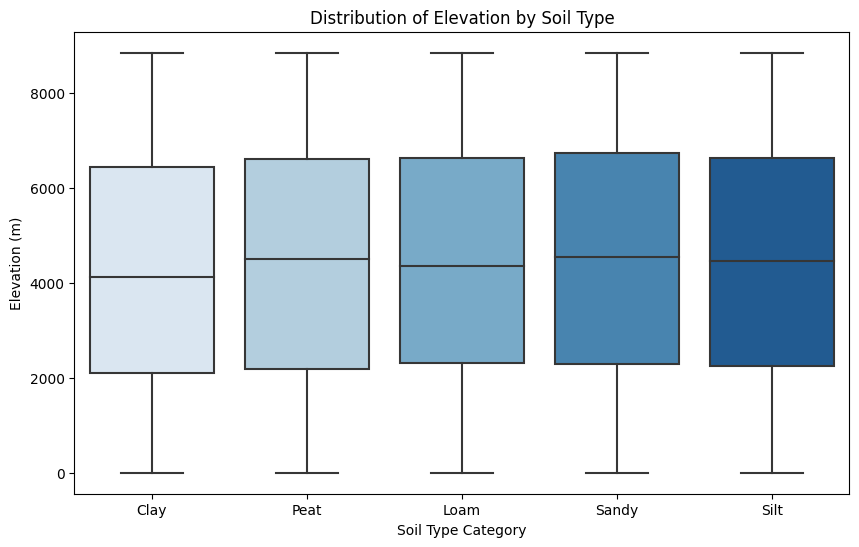

In [21]:
plt.figure(figsize=(10, 6))

# Create a boxplot to visualize Elevation distribution by Soil Type
sns.boxplot(x='Soil Type', y='Elevation (m)', data=data, palette='Blues')

# Add title and axis labels for clarity
plt.title('Distribution of Elevation by Soil Type')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Soil Type Category')
plt.ylabel('Elevation (m)')
plt.show()

In [22]:
encoded_data = pd.get_dummies(data, columns=['Land Cover', 'Soil Type'])

# Define feature set and target variable
features = encoded_data.drop(columns=['Flood Occurred', 'Latitude', 'Longitude'])
target = encoded_data['Flood Occurred']

# Split the data into training and testing sets
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize the feature set
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

In [23]:
rf_model = RandomForestClassifier(random_state=42)

# Fit the model to the scaled training data
rf_model.fit(features_train_scaled, target_train)

RandomForestClassifier(random_state=42)

In [24]:
# Predict the target variable using the scaled test data
predictions = rf_model.predict(features_test_scaled)

# Calculate the accuracy of the model
accuracy_score_value = accuracy_score(target_test, predictions)
print(f"Accuracy: {accuracy_score_value * 100:.2f}%")

# Print the classification report for detailed metrics
print(classification_report(target_test, predictions))


Accuracy: 51.15%
              precision    recall  f1-score   support

           0       0.49      0.51      0.50       966
           1       0.53      0.52      0.52      1034

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



In [25]:
input_data = pd.DataFrame({
    'Rainfall (mm)': [150],
    'Temperature (°C)': [30],
    'Humidity (%)': [70],
    'River Discharge (m³/s)': [20000],
    'Water Level (m)': [5],
    'Elevation (m)': [200],
    'Population Density': [5000],
    'Infrastructure': [1],
    'Historical Floods': [1],
    'Land Cover_Agricultural': [1],
    'Land Cover_Desert': [0],
    'Land Cover_Forest': [0],
    'Land Cover_Urban': [0],
    'Land Cover_Water Body': [0],
    'Soil Type_Clay': [0],
    'Soil Type_Loam': [0],
    'Soil Type_Peat': [0],
    'Soil Type_Sandy': [0],
    'Soil Type_Silt': [0],
})

# Scale the new input data
scaled_input_data = scaler.transform(input_data)

# Predict flood risk using the model
flood_risk_prediction = rf_model.predict(scaled_input_data)
print(f"Flood prediction: {flood_risk_prediction}")


Flood prediction: [1]


In [26]:
print("Map of Locations with Floods and Precipitation Exceeding 200 mm")
precipitation_limit = 200

# Filter the data for high precipitation where floods occurred
flooded_high_precipitation = data[(data['Rainfall (mm)'] > precipitation_limit) & (data['Flood Occurred'] == 1)]

# Calculate the center point of the map based on filtered data
map_center_location = [flooded_high_precipitation['Latitude'].mean(), flooded_high_precipitation['Longitude'].mean()]
flood_map = folium.Map(location=map_center_location, zoom_start=5)

# Create a marker cluster for better visualization
marker_cluster = MarkerCluster().add_to(flood_map)

# Add markers for each location in the filtered data
for _, location_data in flooded_high_precipitation.iterrows():
    folium.Marker(
        location=[location_data['Latitude'], location_data['Longitude']],
        popup=(
            f"Rainfall: {location_data['Rainfall (mm)']} mm, "
            f"Temp: {location_data['Temperature (°C)']} °C, "
            f"Humidity: {location_data['Humidity (%)']}%, "
            f"Water Level: {location_data['Water Level (m)']}, "
            f"Elevation: {location_data['Elevation (m)']} m"
        )
    ).add_to(marker_cluster)

# Display the map
flood_map


Map of Locations with Floods and Precipitation Exceeding 200 mm


In [27]:
print("Map of Locations with High Precipitation (Over 200 mm) Where Floods Did Not Occur")

precipitation_limit = 200

# Filter the data for high precipitation where floods did not occur
non_flooded_high_precipitation = data[(data['Rainfall (mm)'] > precipitation_limit) & (data['Flood Occurred'] == 0)]

# Calculate the center point of the map based on filtered data
map_center_location = [non_flooded_high_precipitation['Latitude'].mean(), non_flooded_high_precipitation['Longitude'].mean()]
flood_map = folium.Map(location=map_center_location, zoom_start=5)

# Create a marker cluster for better visualization
marker_cluster = MarkerCluster().add_to(flood_map)

# Add markers for each location in the filtered data
for _, location_data in non_flooded_high_precipitation.iterrows():
    folium.Marker(
        location=[location_data['Latitude'], location_data['Longitude']],
        popup=(
            f"Rainfall: {location_data['Rainfall (mm)']} mm, "
            f"Temp: {location_data['Temperature (°C)']} °C, "
            f"Humidity: {location_data['Humidity (%)']}%, "
            f"Water Level: {location_data['Water Level (m)']} m, "
            f"Elevation: {location_data['Elevation (m)']} m"
        )
    ).add_to(marker_cluster)

# Display the map
flood_map

Map of Locations with High Precipitation (Over 200 mm) Where Floods Did Not Occur


In [28]:
print("Heatmap of Flood Occurrences ")

# Filter the data for locations where floods occurred
flooded_locations = data[data['Flood Occurred'] == 1]

# Prepare the data for the heatmap
heatmap_data = flooded_locations[['Latitude', 'Longitude']].values.tolist()

# Calculate the center point of the map based on flooded locations
map_center_location = [flooded_locations['Latitude'].mean(), flooded_locations['Longitude'].mean()]
flood_map = folium.Map(location=map_center_location, zoom_start=5)

# Add the heatmap layer to the map
HeatMap(heatmap_data).add_to(flood_map)

# Display the map
flood_map

Heatmap of Flood Occurrences 
